# 17g — γ-score normalization (z-form) on SYNTHETIC data

**Hypothesis:** the γ jumps (17a/17d/18b: T05 → 19.4, 3nW T10 → 32.0) come from the raw
KDE γ-score `dlogG = d_f·∂F/∂γ/H_F² + d_s·∂σ/∂γ/H_S²` — its magnitude scales with 1/H²
and with mismatch distance, saturating the CLIP and taking ~5 MHz steps. μ was fixed by
the σ_ref normalization; γ has no equivalent.

**17g change (ONE thing):** z-form γ-score — one power of bandwidth (unitless distances),
scaled by a fixed reference H_REF (mirrors σ_ref for μ):
`dlogG = (d_f·∂F/∂γ/H_F + d_s·∂σ/∂γ/H_S)/H_REF`. Everything else = 17f exactly.

**Predictions:** (a) no more γ jumps (max |Δγ|/step ≪ 5 MHz); (b) low-count T05 γ recovers
or at least stops exploding; (c) γ RMSE improves on 17f's 2.27; (d) μ untouched (RMSE ~1.40).
**Verdict metric:** γ RMSE + max|Δγ|/step per experiment (printed in the table cell).

## How to read this / what to try

**Diagnosis (FIGS 1–3):**
- Phase-space paths (FIG 1): path should end near the green cross. A path stuck
  mid-way with a low NLL = biased optimum; a flat/high NLL = dead kernel (m/n disease).
- Normalized overlay (FIG 2): all lines should approach 1.0. γ is the sensitive one.
- NLL panel (FIG 3): healthy runs end at NLL ≈ 2–3; dead-kernel runs sit at 20–70.

**Knobs to play with:**
- `LAMBDA_MEAN = 0.3` → mean-matching anchor. Set `0.0` to reproduce the 16-series baseline.
- `H_S_MIN = 0.05` → σ-kernel bandwidth floor (MHz). `0.0` = Scott only.
- `N_WORKERS` / `N_EXP_PARALLEL` → parallelism split (L2/L3); auto-sized to `N_CPUS`.
  With 4 CPUs they are alternatives, not stackable: (1 exp × 4 workers) ≈ (2 × 2) ≈ (4 × 1).
- `N_RUNS` / `N_ITER` for speed; slice `EXPERIMENTS` for quick tests.

**MSE / STE:** mean squared error of the *final optimized values* vs the known
truth across experiments, with the standard error of that MSE (STE = std of the
squared errors / √n). Relative versions are scale-free. Split by power to see
where the bias lives.

In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 16-series)
# ============================================================
EXPERIMENTS = [
    # name,              power, mu_true, sigma_prop, lambda_, gamma_true, n_target
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]

# ---- QUICK TEST: uncomment one of these slices ----
# EXPERIMENTS = EXPERIMENTS[:3]                                        # first 3
# EXPERIMENTS = [e for e in EXPERIMENTS if e['name'] in
#                ('1nW Trans80', '3nW Trans80', '3nW Trans100')]      # the hard ones

print(f'{len(EXPERIMENTS)} experiments configured')

14 experiments configured


In [3]:
# ============================================================
# OPTIMIZATION CONFIG — play with these
# ============================================================
N_RUNS   = 200        # simulated runs per optimization step
N_ITER   = 200        # optimization steps (17f)
LR_MU    = 15.0       # REINFORCE μ learning rate (decays to 30%)
LR_GAMMA = 0.5        # γ learning rate (17f: annealed ×(1-0.5t/N))
SIGMA_REF = 10.0      # 17f: μ-score normalization
GAMMA_SCALE = True    # 17g/18c: z-form γ-score (bandwidth-normalized, fixed reference)
H_REF = 1.0            # fixed reference bandwidth for the γ-score (mirrors σ_ref for μ) -> step = (LR/SIGMA_REF^2)*(E_B[n]-nbar), scale-invariant
CLIP     = 10.0       # gradient clipping
SEED     = 42         # per-step noise seed base (identical to 16-series)

LAMBDA_MEAN = 0.0     # mean-matching weight; 0.0 disables the mean loss
H_S_MIN     = 0.05    # absolute floor for the σ-kernel bandwidth (MHz); 0.0 = Scott only

SYNTH_SEED = 12345    # target generation seed (identical to 16-series -> same targets)

# ============================================================
# PARALLELISM (L2 + L3)
# ============================================================
N_CPUS = os.cpu_count() or 4
N_EXP_PARALLEL = 1    # experiments run at once (L3); must satisfy N_EXP_PARALLEL * N_WORKERS <= N_CPUS
N_WORKERS = 4         # run-loop workers per experiment (L2)
if N_EXP_PARALLEL * N_WORKERS > N_CPUS:
    N_WORKERS = max(1, N_CPUS // N_EXP_PARALLEL)

print(f'config: N_RUNS={N_RUNS}, N_ITER={N_ITER}, LAMBDA_MEAN={LAMBDA_MEAN}, H_S_MIN={H_S_MIN}')
print(f'parallelism: {N_EXP_PARALLEL} exp(s) x {N_WORKERS} workers on {N_CPUS} CPUs')

config: N_RUNS=200, N_ITER=200, LAMBDA_MEAN=0.0, H_S_MIN=0.05
parallelism: 1 exp(s) x 4 workers on 4 CPUs


In [4]:
# ============================================================
# Fixed helpers (identical to the 16-series) + parallel machinery
# ============================================================
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')

def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop):
    # 2D KDE negative log-likelihood + per-data-point scores (as 16-series).
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        # 17g/18c: z-form γ-score — ONE power of bandwidth (unitless distances), fixed reference.
        # Removes the 1/H^2 amplification that saturates the clip and causes γ jumps.
        dlogG = ((d_f * sim_df[None, :]) / h_f + (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    nll_val = -logp.mean()
    return s_mu, s_gamma, nll_val, w

# ---- fork pool: one process per worker, each single-threaded (L2) ----
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker():
    torch.set_num_threads(1)

def _parallel_map(pool, tasks):
    return list(pool.map(_run_one, tasks, chunksize=8))

print('helpers ready')

helpers ready


In [5]:
# ============================================================
# One experiment: joint μ + γ optimization (KDE likelihood + improvements)
# ============================================================
def run_experiment(exp):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        # ---- synthetic target at TRUE values (parallel, same seed as 16-series) ----
        rng_t = np.random.default_rng(SYNTH_SEED)
        tasks_t = []
        for _ in range(exp['n_target']):
            u, b, n = draw_fixed_noise(mu_true, sigma_prop, lam, rng_t)
            tasks_t.append((gamma_true, u.numpy(), b.numpy()))
        res_t = _parallel_map(pool, tasks_t)
        target_f = torch.tensor([r[0] for r in res_t], dtype=torch.float32)
        target_s = torch.tensor([r[1] for r in res_t], dtype=torch.float32)
        SCOTT_EXP = exp['n_target'] ** (-1.0 / 6.0)
        H_F = float(target_f.std()) * SCOTT_EXP
        H_S = max(float(target_s.std()) * SCOTT_EXP, H_S_MIN)

        mu_val = float(mu_init)
        gamma_val = float(gamma_init)
        history = []
        t0 = time.time()

        for step in range(N_ITER):
            rng2 = np.random.default_rng(SEED + step)
            tasks, ns = [], []
            for _ in range(N_RUNS):
                u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
                tasks.append((gamma_val, u.numpy(), b.numpy()))
                ns.append(n)
            res = _parallel_map(pool, tasks)
            fwhms = [r[0] for r in res]
            sigmas = [r[1] for r in res]
            dfs = [r[2] for r in res]
            dsigmas = [r[3] for r in res]

            ft = torch.tensor(fwhms, dtype=torch.float32)
            si_t = torch.tensor(sigmas, dtype=torch.float32)
            nt = torch.tensor(ns, dtype=torch.float32)
            dg_t = torch.tensor(dfs, dtype=torch.float32)
            ds_t = torch.tensor(dsigmas, dtype=torch.float32)

            s_mu, s_gamma, nll_val, w = kde_scores(
                ft, si_t, nt, dg_t, ds_t, target_f, target_s, H_F, H_S, mu_val, sigma_prop)

            # ---- μ: REINFORCE (as 16-series) ----
            B = w.mean(dim=0)
            score = (nt - mu_val) / SIGMA_REF ** 2   # 17f: scale-invariant step (was /sigma_prop^2)
            grad_mu = float(max(min(-(B - B.mean()) @ score, CLIP), -CLIP))

            # ---- γ: KDE channel ----
            grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))

            # ---- mean-matching anchor (kernel-free, alive even when the KDE is dead) ----
            mean_sim = float(ft.mean())
            mean_tgt = float(target_f.mean())
            mean_loss = abs(mean_sim - mean_tgt)
            if LAMBDA_MEAN > 0:
                d_mean_dgamma = float(dg_t.mean())              # d⟨FWHM⟩/dγ (analytic)
                # descent direction: -d|Δ|/dγ = -sign(Δ)·d⟨FWHM⟩/dγ
                grad_gamma_mean = -math.copysign(1.0, mean_sim - mean_tgt) * d_mean_dgamma
                grad_gamma = float(max(min(grad_gamma + LAMBDA_MEAN * grad_gamma_mean, CLIP), -CLIP))

            # ---- updates ----
            lr_mu_decay = LR_MU * (1.0 - step / N_ITER)   # 17f: no decay floor
            mu_val -= lr_mu_decay * grad_mu
            mu_val = max(1.0, min(200.0, mu_val))
            gamma_val -= LR_GAMMA * (1.0 - 0.5 * step / N_ITER) * grad_gamma   # 17f: γ anneal
            gamma_val = max(0.1, min(100.0, gamma_val))

            history.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_gamma=grad_gamma, mean_loss=mean_loss,
                                mean_n=float(nt.mean())))

    return dict(exp=exp['name'], power=exp['power'],
                mu_true=mu_true, gamma_true=gamma_true,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], mean_loss_final=history[-1]['mean_loss'],
                history=history, H_F=H_F, H_S=H_S, t_elapsed=time.time() - t0)

print('run_experiment ready')

run_experiment ready


In [6]:
# ============================================================
# RUN ALL 14 (L3: N_EXP_PARALLEL experiments at once)
# ============================================================
t_all = time.time()
results = []

if N_EXP_PARALLEL <= 1:
    for exp in EXPERIMENTS:
        print(f"Running {exp['name']:>12} ...", end=' ', flush=True)
        r = run_experiment(exp)
        results.append(r)
        print(f"μ {r['mu_true']:.2f} -> {r['mu_final']:.2f} | γ {r['gamma_true']:.1f} -> {r['gamma_final']:.2f} | "
              f"NLL {r['nll_final']:.2f} | {r['t_elapsed']/60:.1f} min", flush=True)
else:
    with _PPE(max_workers=N_EXP_PARALLEL, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        for exp, r in zip(EXPERIMENTS, pool.map(run_experiment, EXPERIMENTS)):
            results.append(r)
            print(f"{exp['name']:>12}: μ {r['mu_true']:.2f} -> {r['mu_final']:.2f} | "
                  f"γ {r['gamma_true']:.1f} -> {r['gamma_final']:.2f} | NLL {r['nll_final']:.2f} | "
                  f"{r['t_elapsed']/60:.1f} min", flush=True)

print(f'\nTotal: {(time.time()-t_all)/60:.1f} min')

Running  1nW Trans05 ... 

μ 9.39 -> 9.92 | γ 8.5 -> 8.36 | NLL 0.94 | 12.0 min


Running  1nW Trans10 ... 

μ 12.37 -> 13.34 | γ 8.5 -> 8.16 | NLL 1.64 | 12.5 min


Running  1nW Trans20 ... 

...

Running  3nW Trans80 ... 

μ 137.54 -> 136.98 | γ 14.1 -> 14.11 | NLL 2.99 | 13.7 min


Running 3nW Trans100 ... 

μ 175.71 -> 178.19 | γ 14.1 -> 14.16 | NLL 2.78 | 13.8 min



Total: 195.0 min


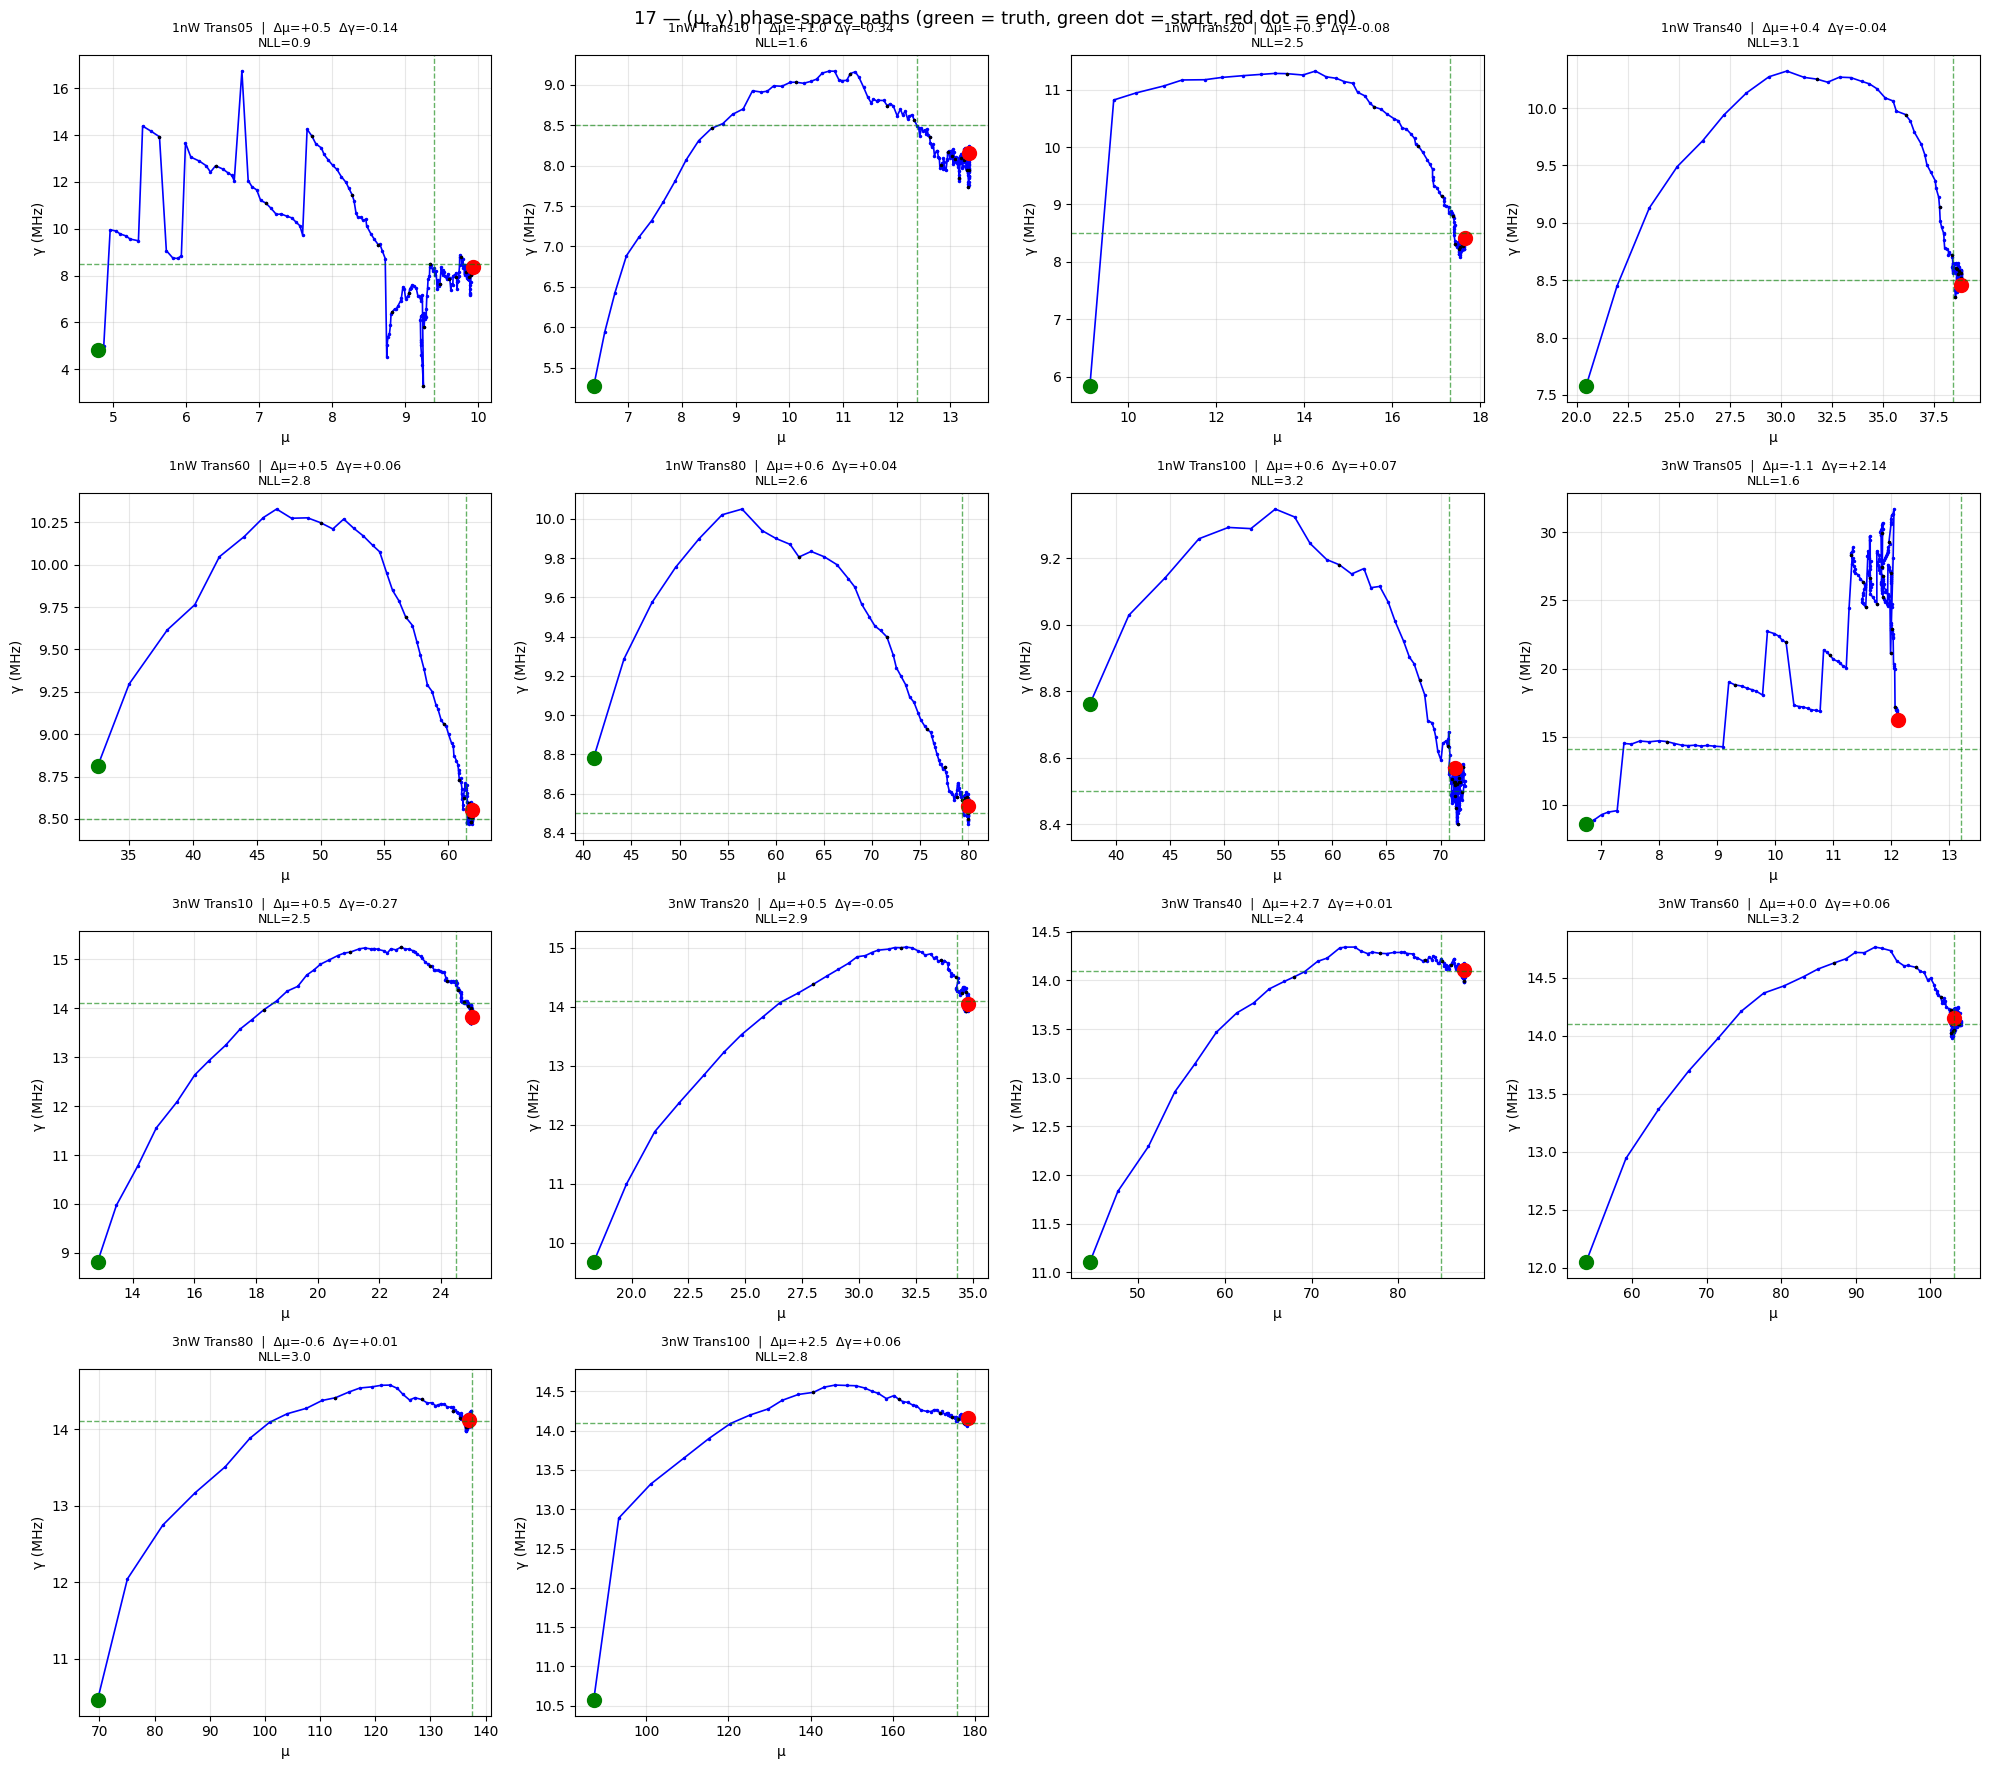

In [7]:
# ============================================================
# FIG 1 — optimization paths in (μ, γ) phase space (quick diagnosis)
# ============================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
for idx, r in enumerate(results):
    ax = axes[idx // 4][idx % 4]
    hs = r['history']
    mus = [h['mu'] for h in hs]
    gams = [h['gamma'] for h in hs]
    ax.plot(mus, gams, 'b.-', lw=1.2, ms=3)
    ax.plot(mus[::10], gams[::10], 'k.', ms=3)                    # every 10th step
    ax.plot(mus[0], gams[0], 'go', ms=10, label='start')
    ax.plot(mus[-1], gams[-1], 'ro', ms=10, label='end')
    ax.axvline(r['mu_true'], color='g', ls='--', lw=1, alpha=0.6)
    ax.axhline(r['gamma_true'], color='g', ls='--', lw=1, alpha=0.6)
    ax.set_title(f"{r['exp']}  |  Δμ={r['mu_final']-r['mu_true']:+.1f}  Δγ={r['gamma_final']-r['gamma_true']:+.2f}\nNLL={r['nll_final']:.1f}", fontsize=9)
    ax.set_xlabel('μ'); ax.set_ylabel('γ (MHz)')
    ax.grid(alpha=0.3)
for idx in range(len(results), 16):
    axes[idx // 4][idx % 4].axis('off')
plt.suptitle('17 — (μ, γ) phase-space paths (green = truth, green dot = start, red dot = end)', fontsize=13)
plt.tight_layout()
plt.show()

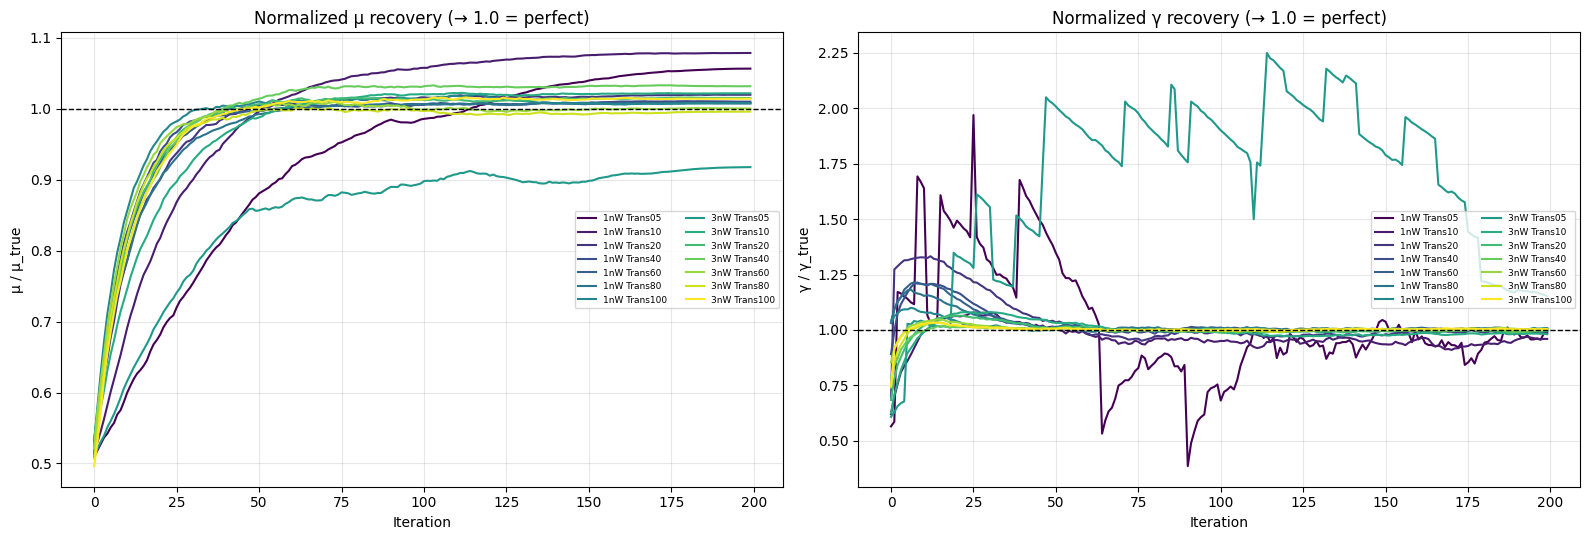

In [8]:
# ============================================================
# FIG 2 — normalized trajectories overlay (→ 1.0 = perfect recovery)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
for r, c in zip(results, colors):
    hs = r['history']
    steps = [h['step'] for h in hs]
    axes[0].plot(steps, [h['mu'] / r['mu_true'] for h in hs], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(steps, [h['gamma'] / r['gamma_true'] for h in hs], color=c, lw=1.5, label=r['exp'])
for ax, ylab in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_xlabel('Iteration'); ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout()
plt.show()

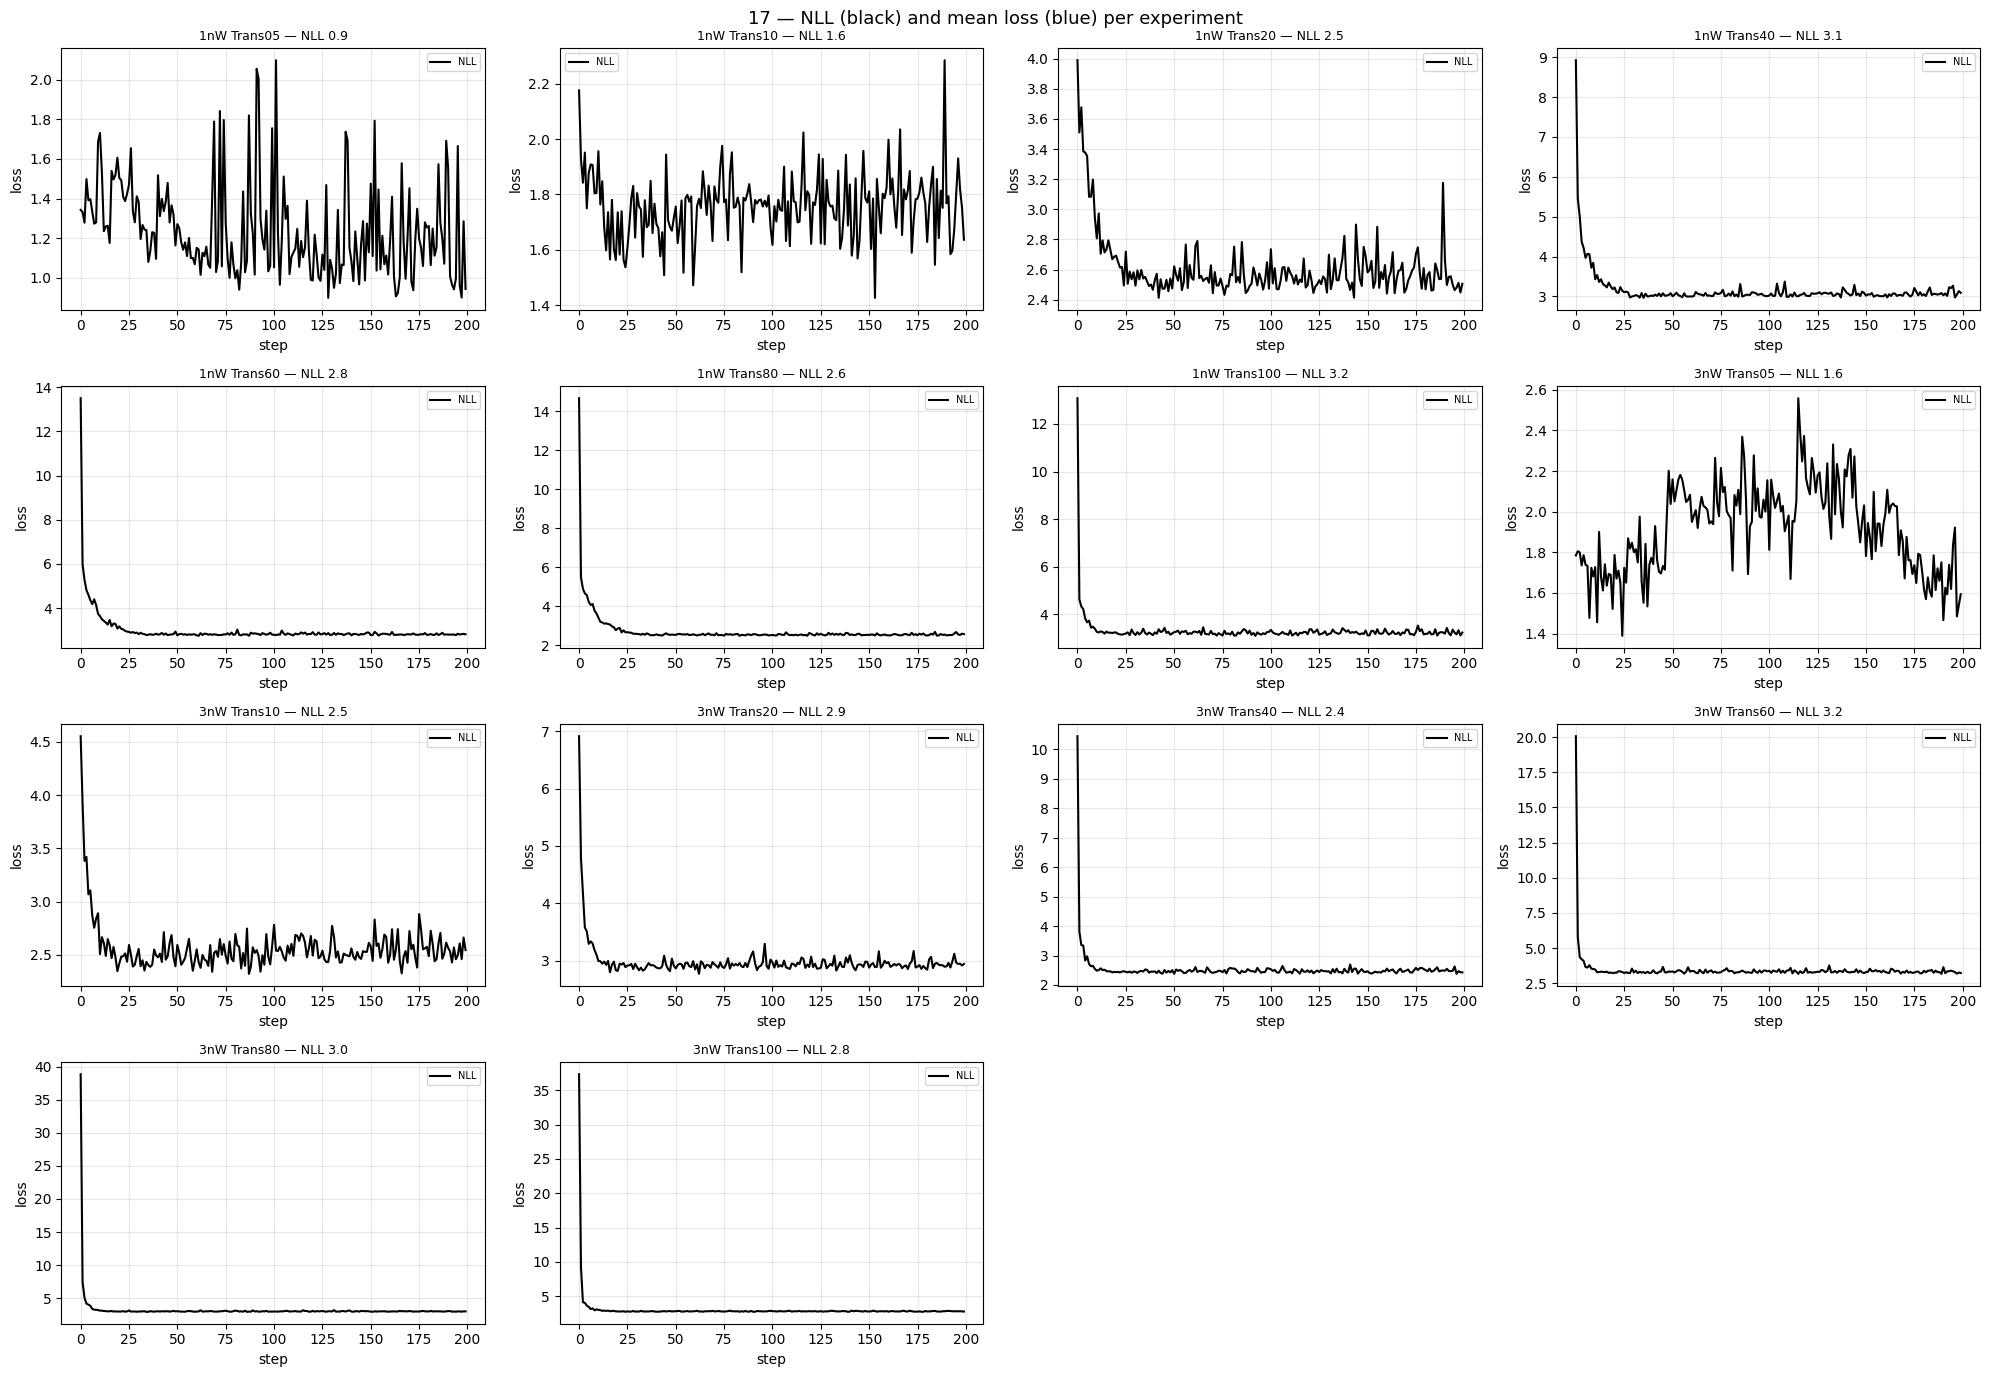

In [9]:
# ============================================================
# FIG 3 — NLL per experiment (dead kernel shows up as high/flat NLL)
# ============================================================
fig, axes = plt.subplots(4, 4, figsize=(20, 14))
for idx, r in enumerate(results):
    ax = axes[idx // 4][idx % 4]
    hs = r['history']
    ax.plot([h['step'] for h in hs], [h['nll'] for h in hs], 'k-', lw=1.5, label='NLL')
    if LAMBDA_MEAN > 0:
        ax.plot([h['step'] for h in hs], [h['mean_loss'] for h in hs], 'b-', lw=1.0, alpha=0.7, label='mean loss')
    ax.set_title(f"{r['exp']} — NLL {r['nll_final']:.1f}", fontsize=9)
    ax.set_xlabel('step'); ax.set_ylabel('loss')
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
for idx in range(len(results), 16):
    axes[idx // 4][idx % 4].axis('off')
plt.suptitle('17 — NLL (black) and mean loss (blue) per experiment', fontsize=13)
plt.tight_layout()
plt.show()

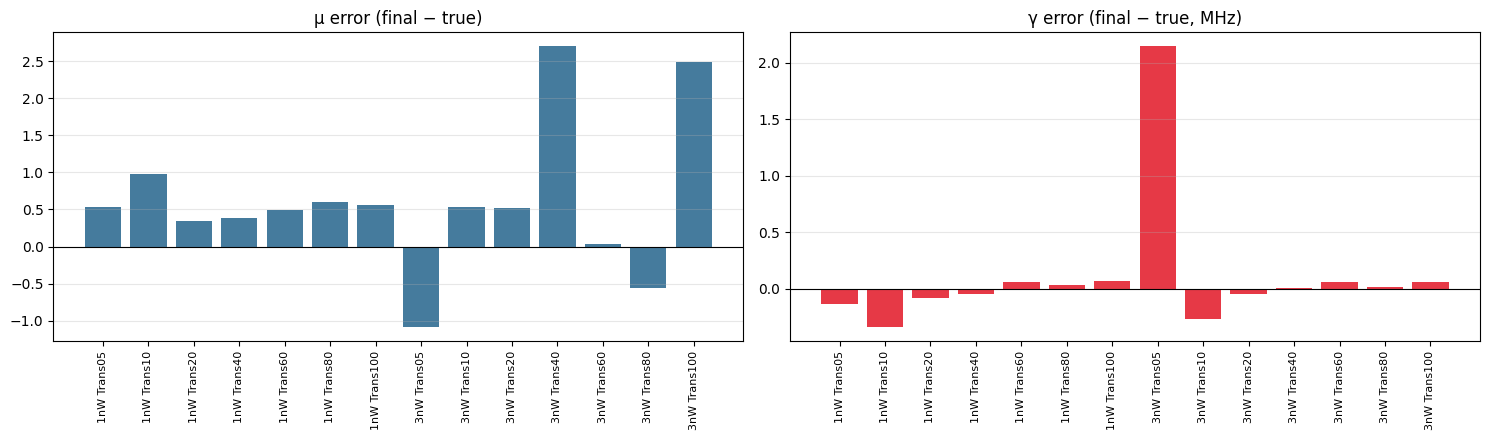

In [10]:
# ============================================================
# FIG 4 — final errors per experiment
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
names = [r['exp'] for r in results]
dmu = np.array([r['mu_final'] - r['mu_true'] for r in results])
dg = np.array([r['gamma_final'] - r['gamma_true'] for r in results])
x = np.arange(len(results))
axes[0].bar(x, dmu, color='#457b9d')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=90, fontsize=8)
axes[0].set_title('μ error (final − true)'); axes[0].grid(alpha=0.3, axis='y')
axes[1].bar(x, dg, color='#e63946')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=90, fontsize=8)
axes[1].set_title('γ error (final − true, MHz)'); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# RESULTS TABLE + MSE / STE
# ============================================================
print(f"{'exp':<12} {'μ_true':>7} {'μ_final':>8} {'Δμ':>7} | {'γ_true':>6} {'γ_final':>8} {'Δγ':>7} | {'NLL':>6}")
print('-' * 78)
for r in results:
    print(f"{r['exp']:<12} {r['mu_true']:>7.2f} {r['mu_final']:>8.2f} {r['mu_final']-r['mu_true']:>+7.2f} | "
          f"{r['gamma_true']:>6.1f} {r['gamma_final']:>8.2f} {r['gamma_final']-r['gamma_true']:>+7.2f} | {r['nll_final']:>6.2f}")

def mse_stats(err):
    err = np.asarray(err, dtype=float)
    sq = err ** 2
    mse = sq.mean()
    ste = sq.std(ddof=1) / math.sqrt(len(sq))   # standard error of the MSE estimate
    return mse, ste, math.sqrt(mse), err.mean()

dmu = np.array([r['mu_final'] - r['mu_true'] for r in results])
dg = np.array([r['gamma_final'] - r['gamma_true'] for r in results])
rdmu = dmu / np.array([r['mu_true'] for r in results])
rdg = dg / np.array([r['gamma_true'] for r in results])

print('\n=== MSE / STE over the %d experiments ===' % len(results))
for label, err, rel in [('μ (photons)', dmu, rdmu), ('γ (MHz)', dg, rdg)]:
    mse, ste, rmse, bias = mse_stats(err)
    _, _, rmse_rel, bias_rel = mse_stats(rel)
    print(f'{label:>12}: bias={bias:+.3f} | MSE={mse:.4f} ± {ste:.4f} (STE) | RMSE={rmse:.3f} | '
          f'rel-RMSE={rmse_rel*100:.1f}% | rel-bias={bias_rel*100:+.1f}%')

for p in ['1nW', '3nW']:
    sel = [i for i, r in enumerate(results) if r['power'] == p]
    if not sel:
        continue
    print(f'\n--- {p} ({len(sel)} experiments) ---')
    for label, err, rel in [('μ (photons)', dmu[sel], rdmu[sel]), ('γ (MHz)', dg[sel], rdg[sel])]:
        mse, ste, rmse, bias = mse_stats(err)
        _, _, rmse_rel, bias_rel = mse_stats(rel)
        print(f'  {label:>12}: bias={bias:+.3f} | MSE={mse:.4f} ± {ste:.4f} (STE) | RMSE={rmse:.3f} | '
              f'rel-RMSE={rmse_rel*100:.1f}% | rel-bias={bias_rel*100:+.1f}%')
# jump diagnostics: max single-step γ change per experiment (the "big jumps" from 17a/17d/18b)
print()
print(f"{'exp':<12} {'max|Δγ|/step':>13}")
for r in results:
    hs = r['history']
    jumps = [abs(hs[i+1]['gamma'] - hs[i]['gamma']) for i in range(len(hs)-1)]
    print(f"{r['exp']:<12} {max(jumps) if jumps else 0:>13.2f}")

exp           μ_true  μ_final      Δμ | γ_true  γ_final      Δγ |    NLL
------------------------------------------------------------------------------
1nW Trans05     9.39     9.92   +0.53 |    8.5     8.36   -0.14 |   0.94
1nW Trans10    12.37    13.34   +0.97 |    8.5     8.16   -0.34 |   1.64
1nW Trans20    17.32    17.66   +0.34 |    8.5     8.42   -0.08 |   2.51
1nW Trans40    38.41    38.79   +0.39 |    8.5     8.46   -0.04 |   3.09
1nW Trans60    61.37    61.86   +0.49 |    8.5     8.56   +0.06 |   2.81
1nW Trans80    79.36    79.96   +0.60 |    8.5     8.54   +0.04 |   2.57
1nW Trans100   70.82    71.38   +0.56 |    8.5     8.57   +0.07 |   3.23
3nW Trans05    13.20    12.12   -1.09 |   14.1    16.24   +2.14 |   1.59
3nW Trans10    24.48    25.01   +0.53 |   14.1    13.83   -0.27 |   2.55
3nW Trans20    34.28    34.80   +0.52 |   14.1    14.05   -0.05 |   2.94
3nW Trans40    84.89    87.59   +2.70 |   14.1    14.11   +0.01 |   2.43
3nW Trans60   103.20   103.24   +0.04 |   14.